In [6]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sentence_transformers import SentenceTransformer

from src.db_utils import load_sql

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Модули импортированы")

Модули импортированы


In [7]:
df = load_sql("SELECT * FROM documents")
print(f"Всего отзывов: {len(df)}")
print(f"Распределение:\n{df['category'].value_counts()}")

Всего отзывов: 131669
Распределение:
category
pos    87138
neu    24704
neg    19827
Name: count, dtype: int64


In [8]:
MODEL_NAME = 'paraphrase-multilingual-MiniLM-L12-v2'
RU_MODEL_NAME = 'cointegrated/rubert-tiny2'

print(f"Загружаем модель {RU_MODEL_NAME}...")
embedder = SentenceTransformer(RU_MODEL_NAME)
print("Модель загружена!")

Загружаем модель cointegrated/rubert-tiny2...


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Модель загружена!


In [9]:
print("Векторизуем все отзывы...")
start_time = time.time()

embeddings = embedder.encode(
    df['text'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

elapsed = time.time() - start_time
print(f"Готово за {elapsed:.1f} секунд!")
print(f"Размер матрицы: {embeddings.shape}")
print(f"Размер в памяти: {embeddings.nbytes / 1024 / 1024:.1f} МБ")

Векторизуем все отзывы...


Batches:   0%|          | 0/4115 [00:00<?, ?it/s]

Готово за 2784.8 секунд!
Размер матрицы: (131669, 312)
Размер в памяти: 156.7 МБ


In [10]:
df_train, df_val = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['category']
)

train_idx = df_train.index.tolist()
val_idx = df_val.index.tolist()

X_train_emb = embeddings[train_idx]
X_val_emb = embeddings[val_idx]

y_train = df_train['category']
y_val = df_val['category']

print(f"Train: {len(X_train_emb)} отзывов")
print(f"Validation: {len(X_val_emb)} отзывов")

Train: 105335 отзывов
Validation: 26334 отзывов


In [11]:
model_emb = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

print("Обучаем модель на эмбеддингах...")
start_time = time.time()
model_emb.fit(X_train_emb, y_train)
elapsed = time.time() - start_time

print(f"Обучение завершено за {elapsed:.2f} секунд")

Обучаем модель на эмбеддингах...
Обучение завершено за 7.98 секунд


In [12]:
y_pred_emb = model_emb.predict(X_val_emb)
y_proba_emb = model_emb.predict_proba(X_val_emb)

print(f"Первые 5 предсказаний:")
for i in range(10):
    print(f"  Истинный: {y_val.iloc[i]}, Предсказанный: {y_pred_emb[i]}")
    print(f"  Вероятности: neg={y_proba_emb[i][0]:.3f}, "
          f"neu={y_proba_emb[i][1]:.3f}, pos={y_proba_emb[i][2]:.3f}")
    print()

Первые 5 предсказаний:
  Истинный: pos, Предсказанный: neg
  Вероятности: neg=0.494, neu=0.339, pos=0.167

  Истинный: pos, Предсказанный: neu
  Вероятности: neg=0.095, neu=0.470, pos=0.436

  Истинный: neg, Предсказанный: neg
  Вероятности: neg=0.419, neu=0.405, pos=0.176

  Истинный: neg, Предсказанный: neg
  Вероятности: neg=0.532, neu=0.253, pos=0.215

  Истинный: neu, Предсказанный: neu
  Вероятности: neg=0.117, neu=0.643, pos=0.240

  Истинный: pos, Предсказанный: pos
  Вероятности: neg=0.207, neu=0.365, pos=0.427

  Истинный: neg, Предсказанный: pos
  Вероятности: neg=0.129, neu=0.256, pos=0.614

  Истинный: neu, Предсказанный: pos
  Вероятности: neg=0.235, neu=0.249, pos=0.516

  Истинный: neg, Предсказанный: neu
  Вероятности: neg=0.257, neu=0.578, pos=0.164

  Истинный: neu, Предсказанный: neg
  Вероятности: neg=0.786, neu=0.187, pos=0.027



In [13]:
accuracy_emb = accuracy_score(y_val, y_pred_emb)
report_emb = classification_report(y_val, y_pred_emb)

print(f"Accuracy (эмбеддинги): {accuracy_emb:.4f}")
print("\nОтчёт по классификации:")
print(report_emb)

Accuracy (эмбеддинги): 0.6587

Отчёт по классификации:
              precision    recall  f1-score   support

         neg       0.50      0.72      0.59      3965
         neu       0.34      0.48      0.39      4941
         pos       0.89      0.70      0.78     17428

    accuracy                           0.66     26334
   macro avg       0.58      0.63      0.59     26334
weighted avg       0.73      0.66      0.68     26334



In [14]:
vectorizer_tfidf = joblib.load('../models/tfidf_vectorizer_v1.pkl')
model_tfidf = joblib.load('../models/logreg_v1.pkl')

X_val_tfidf = vectorizer_tfidf.transform(df_val['text'])

y_pred_tfidf = model_tfidf.predict(X_val_tfidf)

accuracy_tfidf = accuracy_score(y_val, y_pred_tfidf)
report_tfidf = classification_report(y_val, y_pred_tfidf, output_dict=True)

print(f"Accuracy (TF-IDF): {accuracy_tfidf:.4f}")

Accuracy (TF-IDF): 0.7063


Сравнение моделей:
 Метрика   TF-IDF  Эмбеддинги   Разница
Accuracy 0.706273    0.658730 -0.047543
  F1 neg 0.650993    0.592455 -0.058538
  F1 neu 0.420472    0.394578 -0.025894
  F1 pos 0.823963    0.781260 -0.042703


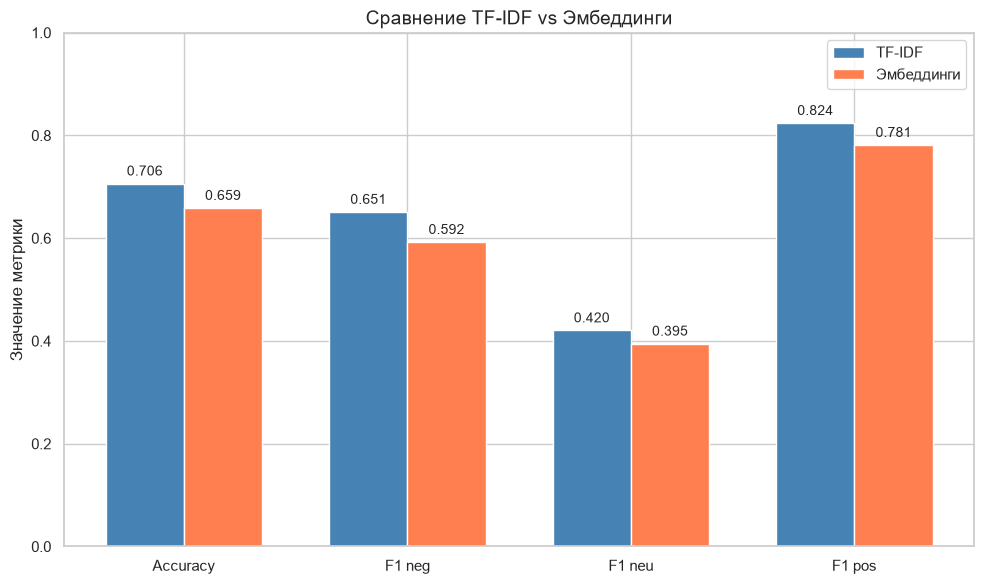

In [15]:
comparison = pd.DataFrame({
    'Метрика': ['Accuracy', 'F1 neg', 'F1 neu', 'F1 pos'],
    'TF-IDF': [
        accuracy_tfidf,
        report_tfidf['neg']['f1-score'],
        report_tfidf['neu']['f1-score'],
        report_tfidf['pos']['f1-score']
    ],
    'Эмбеддинги': [
        accuracy_emb,
        classification_report(y_val, y_pred_emb, output_dict=True)['neg']['f1-score'],
        classification_report(y_val, y_pred_emb, output_dict=True)['neu']['f1-score'],
        classification_report(y_val, y_pred_emb, output_dict=True)['pos']['f1-score']
    ]
})

comparison['Разница'] = comparison['Эмбеддинги'] - comparison['TF-IDF']

print("Сравнение моделей:")
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparison['Метрика']))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['TF-IDF'], width, label='TF-IDF', color='steelblue')
bars2 = ax.bar(x + width/2, comparison['Эмбеддинги'], width, label='Эмбеддинги', color='coral')

ax.set_ylabel('Значение метрики', fontsize=12)
ax.set_title('Сравнение TF-IDF vs Эмбеддинги', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparison['Метрика'])
ax.legend()
ax.set_ylim(0, 1)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../data/processed/tfidf_vs_embeddings_comparison.png', dpi=150)
plt.show()

In [16]:
joblib.dump(model_emb, '../models/logreg_embeddings_v1.pkl')
print("Модель на эмбеддингах сохранена: models/logreg_embeddings_v1.pkl")

np.save('../data/processed/all_review_embeddings.npy', embeddings)
print(f"Все эмбеддинги сохранены: {embeddings.shape}")

Модель на эмбеддингах сохранена: models/logreg_embeddings_v1.pkl
Все эмбеддинги сохранены: (131669, 312)
